# 🚘 CrashLens — Vehicle Part Segmentation
## Stage 2 / exp02 — Fine-tune on CROPPED carparts-seg images

Reference: `docs/segmentation_finetuning.md` (§5 Stage 2, §7 logging convention, §8 notes template), `segmentation_baseline_eval.ipynb` (exp01).

**Reference to beat (exp01_baseline_pretrained, real CrashLens images, pretrained weights, no fine-tuning):**
- `cropped/` (real close-ups): **10%** detection rate
- `full/`: **95%** detection rate

**Hypothesis under test.** The pretrained carparts-seg model was itself trained on full-car-style framing, so it may simply never have seen close-up crops during its own training — not a generalization failure so much as an out-of-distribution framing problem. If that's right, fine-tuning the SAME checkpoint on a cropped-around-instance version of the carparts-seg training data should recover detection on our real close-ups, without needing any CrashLens-specific labels yet.

**One variable vs exp01.** Same pretrained checkpoint, same eval protocol (conf/iou/imgsz), same real evaluation images. The only thing that changes is: this checkpoint gets fine-tuned on synthetically-cropped carparts-seg data before evaluation.

**This notebook is NOT executed here — scaffolded only, per your instruction. You run it in Colab.**

**Assumptions — confirm before running:**
1. **Drive root.** Reuses the same root as exp01 (`MyDrive/carparts/segmentation/...`), which itself deviates from the doc's literal example (`Drive/CrashLens/segmentation/...`) — carried forward for consistency with exp01 rather than re-flagging a new deviation.
2. **`MODEL_SOURCE`** (Section 3) is a placeholder — set it to the *exact same* checkpoint path/hub-id exp01 evaluated. If it doesn't match exp01's, this stops being a single-variable comparison.
3. **`REAL_DATA_ROOT`** (Section 3) is a placeholder — set it to the *same* Drive folder (`full/`, `cropped/`) exp01 evaluated, for an apples-to-apples before/after.
4. **`CONF_THRESH`/`IOU_THRESH`/`IMG_SIZE`/`IMG_EXTS`** are hardcoded to exp01's values (0.25 / 0.7 / 640) — do not change these when running, or the comparison isn't controlled anymore.
5. **`EXP01_REFERENCE`** (Section 9) hardcodes 10%/95% from your message. If exp01's actual `results_summary.csv`/`notes.md` differ slightly, update those two numbers before running Section 9.
6. **No "community training notebook" file exists in this repo** (checked via search). Section 7's training call uses Ultralytics' own official documented example for `carparts-seg.yaml` (`epochs=100, imgsz=640`, otherwise library defaults) as the closest available reference recipe — flag it if you have a specific different notebook in mind; swap the recipe in before running.
7. **Crop parameters** (margin 15–60% of the instance bbox, jitter ±10% of crop size, minimum crop size 48px) are reasonable defaults, not something you specified — tune in Section 3 if needed.
8. **Dataset auto-download layout** — `carparts-seg.yaml` resolves via Ultralytics' own `check_det_dataset`, wherever it decides to place the download; the notebook reads the resolved paths back programmatically rather than assuming a fixed folder layout.
9. **Build location.** Crops are built on local Colab disk (`/content/...`) for training I/O speed, then archived (copied) to Drive as the frozen, versioned dataset. Training reads from the local copy, not Drive, for speed — common Colab practice. Say so if you'd rather train directly against Drive-mounted files.
10. Per your constraints: no backend/Flutter files touched, labor-hours table untouched — this notebook is fully standalone.

## 📁 Section 1 — Drive mount & experiment folders

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

DRIVE_ROOT = '/content/drive/MyDrive/carparts/segmentation'
EXP_ID     = 'exp02_finetune_cropped_carparts'
EXP_DIR    = os.path.join(DRIVE_ROOT, 'experiments', EXP_ID)

for sub in ['weights', 'val_preds/full', 'val_preds/cropped']:
    os.makedirs(os.path.join(EXP_DIR, sub), exist_ok=True)

print('✅ Drive mounted and experiment folders ready.')
print(f'   Experiment root: {EXP_DIR}')

Mounted at /content/drive
✅ Drive mounted and experiment folders ready.
   Experiment root: /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts


## 📦 Section 2 — Install Ultralytics

In [2]:
!pip install -q ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 46.7/112.6 GB disk)


## ⚙️ Section 3 — Configuration (edit before running)

In [13]:
import torch

# ── IDENTITY WITH exp01 — must match exactly for a controlled comparison ─────
MODEL_SOURCE  = '/content/drive/MyDrive/carparts/weights/best.pt'  # TODO: same value exp01 used
REAL_DATA_ROOT = '/content/drive/MyDrive/carparts'  # TODO: same Drive folder (full/, cropped/) exp01 evaluated
CONF_THRESH   = 0.25   # identical to exp01 — do not change
IOU_THRESH    = 0.7    # identical to exp01 — do not change
IMG_SIZE      = 640    # identical to exp01 — do not change
IMG_EXTS      = ('.jpg', '.jpeg', '.png')
SUBFOLDERS    = ['full', 'cropped']

# ── New in exp02 — the one variable under test ───────────────────────────────
SEED               = 42
DATASET_VERSION    = 'v1_cropped_carparts'
LOCAL_BUILD_ROOT   = '/content/carparts_crops_build'   # fast local disk, used for the actual training run
DRIVE_DATASETS_DIR = os.path.join(DRIVE_ROOT, 'datasets', DATASET_VERSION)  # frozen, versioned archive (docs §7)

# Crop-generation parameters — reasonable defaults, not specified by the task; tune here if needed
MIN_MARGIN_FRAC = 0.15   # min context margin around an instance's bbox, as a fraction of its own bbox size
MAX_MARGIN_FRAC = 0.60   # max context margin, same units
JITTER_FRAC     = 0.10   # random crop-center jitter, as a fraction of the (margined) crop size
MIN_CROP_PX     = 48     # skip a proposed crop smaller than this in either dimension

# Training recipe — see Section 7 / assumption #6: no community notebook found in-repo,
# so this mirrors Ultralytics' own documented carparts-seg example (epochs=100, imgsz=640),
# with every other hyperparameter left at library defaults.
EPOCHS = 100

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Config set. Device={DEVICE}')
print(f'   MODEL_SOURCE   : {MODEL_SOURCE}')
print(f'   REAL_DATA_ROOT : {REAL_DATA_ROOT}')
print(f'   DATASET_VERSION: {DATASET_VERSION}  (seed={SEED})')

✅ Config set. Device=cuda
   MODEL_SOURCE   : /content/drive/MyDrive/carparts/weights/best.pt
   REAL_DATA_ROOT : /content/drive/MyDrive/carparts
   DATASET_VERSION: v1_cropped_carparts  (seed=42)


## 🌐 Section 4 — Fetch the Ultralytics carparts-seg dataset (auto-download)

In [4]:
from ultralytics.data.utils import check_det_dataset

# check_det_dataset auto-downloads carparts-seg.yaml's data if not already present locally,
# and resolves train/val/test to absolute paths — read back programmatically rather than
# assumed, since the exact on-disk layout of the auto-download is an Ultralytics internal.
data_info = check_det_dataset('carparts-seg.yaml', autodownload=True)

print('✅ carparts-seg dataset ready.')
print(f"   train: {data_info.get('train')}")
print(f"   val  : {data_info.get('val')}")
print(f"   test : {data_info.get('test')}   ← will NOT be touched by this notebook")
print(f"   classes ({data_info.get('nc', len(data_info['names']))}): {list(data_info['names'].values())}")


WARNING ⚠️ Dataset 'carparts-seg.yaml' images not found, missing path '/content/datasets/carparts-seg/images/val'
Unzipping /content/datasets/carparts-seg.zip to /content/datasets/carparts-seg...: 100% ━━━━━━━━━━━━ 7675/7675 3.3Kfiles/s 2.3s
Dataset download success ✅ (7.9s), saved to /content/datasets

✅ carparts-seg dataset ready.
   train: /content/datasets/carparts-seg/images/train
   val  : /content/datasets/carparts-seg/images/val
   test : /content/datasets/carparts-seg/images/test   ← will NOT be touched by this notebook
   classes (23): ['back_bumper', 'back_door', 'back_glass', 'back_left_door', 'back_left_light', 'back_light', 'back_right_door', 'back_right_light', 'front_bumper', 'front_door', 'front_glass', 'front_left_door', 'front_left_light', 'front_light', 'front_right_door', 'front_right_light', 'hood', 'left_mirror', 'object', 'right_mirror', 'tailgate', 'trunk', 'wheel']


## ✂️ Section 5 — Build the cropped dataset (crop AROUND each annotated instance)

For every annotated instance in every train/val image: take its bbox, expand by a random context margin, jitter the crop position, clip to image bounds, then keep only the instances (this one and any others) whose full polygon lands inside the crop — anything not fully inside is dropped rather than truncated, to avoid corrupting mask polygons. If nothing survives, the crop is skipped. Kept polygons are remapped into the crop's own coordinate frame. One crop is generated per instance, so a busy image yields several (different, non-uniform) crops.

In [5]:
import random
from pathlib import Path
import cv2

try:
    from ultralytics.data.utils import img2label_paths
except ImportError:
    def img2label_paths(img_paths):
        # Fallback mirroring Ultralytics' own convention: .../images/... -> .../labels/..., ext -> .txt
        sa, sb = f'{os.sep}images{os.sep}', f'{os.sep}labels{os.sep}'
        return [sb.join(p.rsplit(sa, 1)).rsplit('.', 1)[0] + '.txt' for p in img_paths]


def load_instances(img_path, w, h):
    label_path = Path(img2label_paths([str(img_path)])[0])
    if not label_path.exists():
        return []
    instances = []
    for line in label_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        parts = line.split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        xs = [coords[i] * w for i in range(0, len(coords), 2)]
        ys = [coords[i] * h for i in range(1, len(coords), 2)]
        instances.append({'cls': cls_id, 'xs': xs, 'ys': ys})
    return instances


def instance_bbox(inst):
    return min(inst['xs']), min(inst['ys']), max(inst['xs']), max(inst['ys'])


def instance_inside(inst, cx0, cy0, cx1, cy1):
    return all(cx0 <= x <= cx1 for x in inst['xs']) and all(cy0 <= y <= cy1 for y in inst['ys'])


def remap_instance(inst, cx0, cy0, cx1, cy1):
    cw, ch = cx1 - cx0, cy1 - cy0
    new_xs = [min(1.0, max(0.0, (x - cx0) / cw)) for x in inst['xs']]
    new_ys = [min(1.0, max(0.0, (y - cy0) / ch)) for y in inst['ys']]
    coords = []
    for x, y in zip(new_xs, new_ys):
        coords.extend([x, y])
    return inst['cls'], coords


def generate_crops_for_split(images_dir, out_images_dir, out_labels_dir, rng):
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_labels_dir, exist_ok=True)
    image_files = sorted([f for f in Path(images_dir).iterdir() if f.suffix.lower() in IMG_EXTS])

    n_written = 0
    n_skipped_empty = 0
    n_kept = 0
    n_dropped = 0

    for img_path in image_files:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        instances = load_instances(img_path, w, h)
        if not instances:
            continue

        for anchor_idx, anchor in enumerate(instances):
            ax0, ay0, ax1, ay1 = instance_bbox(anchor)
            bw, bh = ax1 - ax0, ay1 - ay0
            if bw <= 0 or bh <= 0:
                continue

            margin_frac = rng.uniform(MIN_MARGIN_FRAC, MAX_MARGIN_FRAC)
            mx, my = bw * margin_frac, bh * margin_frac
            cx0, cy0, cx1, cy1 = ax0 - mx, ay0 - my, ax1 + mx, ay1 + my

            crop_w, crop_h = cx1 - cx0, cy1 - cy0
            jx = rng.uniform(-JITTER_FRAC, JITTER_FRAC) * crop_w
            jy = rng.uniform(-JITTER_FRAC, JITTER_FRAC) * crop_h
            cx0, cx1 = cx0 + jx, cx1 + jx
            cy0, cy1 = cy0 + jy, cy1 + jy

            cx0, cy0 = max(0.0, cx0), max(0.0, cy0)
            cx1, cy1 = min(float(w), cx1), min(float(h), cy1)

            icx0, icy0, icx1, icy1 = int(round(cx0)), int(round(cy0)), int(round(cx1)), int(round(cy1))
            if (icx1 - icx0) < MIN_CROP_PX or (icy1 - icy0) < MIN_CROP_PX:
                n_skipped_empty += 1
                continue

            # Jitter can push part of the anchor's own bbox outside the final crop —
            # in that case the anchor itself gets dropped below and the crop ends up
            # empty (handled by the `if not kept_lines` branch). Expected, not a bug.
            kept_lines = []
            for inst in instances:
                if instance_inside(inst, icx0, icy0, icx1, icy1):
                    cls_id, coords = remap_instance(inst, icx0, icy0, icx1, icy1)
                    kept_lines.append(f"{cls_id} " + " ".join(f"{c:.6f}" for c in coords))
                    n_kept += 1
                else:
                    n_dropped += 1

            if not kept_lines:
                n_skipped_empty += 1
                continue

            crop_img = img[icy0:icy1, icx0:icx1]
            out_stem = f'{img_path.stem}_i{anchor_idx}'
            cv2.imwrite(os.path.join(out_images_dir, f'{out_stem}.jpg'), crop_img)
            with open(os.path.join(out_labels_dir, f'{out_stem}.txt'), 'w') as f:
                f.write('\n'.join(kept_lines) + '\n')
            n_written += 1

    return {
        'images_dir': str(images_dir),
        'crops_written': n_written,
        'crops_skipped_empty': n_skipped_empty,
        'instances_kept': n_kept,
        'instances_dropped': n_dropped,
    }


print('✅ Crop-generation functions defined.')

✅ Crop-generation functions defined.


In [6]:
SPLITS_TO_CROP = ['train', 'val']  # test is NEVER touched, per instructions
assert 'test' not in SPLITS_TO_CROP

rng = random.Random(SEED)  # single seeded RNG, consumed in a fixed (sorted-file) order -> reproducible
crop_stats = {}

for split in SPLITS_TO_CROP:
    images_dir = data_info[split]
    if isinstance(images_dir, list):
        images_dir = images_dir[0]  # defensive: carparts-seg.yaml defines one dir per split
    out_images_dir = os.path.join(LOCAL_BUILD_ROOT, split, 'images')
    out_labels_dir = os.path.join(LOCAL_BUILD_ROOT, split, 'labels')
    print(f'▶ Building {split} crops from {images_dir} ...')
    crop_stats[split] = generate_crops_for_split(images_dir, out_images_dir, out_labels_dir, rng)
    print(f'   {crop_stats[split]}')

print('\n🚫 test split NOT cropped/touched (frozen), per instructions.')

▶ Building train crops from /content/datasets/carparts-seg/images/train ...
   {'images_dir': '/content/datasets/carparts-seg/images/train', 'crops_written': 15672, 'crops_skipped_empty': 1061, 'instances_kept': 25499, 'instances_dropped': 70413}
▶ Building val crops from /content/datasets/carparts-seg/images/val ...
   {'images_dir': '/content/datasets/carparts-seg/images/val', 'crops_written': 1934, 'crops_skipped_empty': 108, 'instances_kept': 2984, 'instances_dropped': 8084}

🚫 test split NOT cropped/touched (frozen), per instructions.


## 🗃️ Section 6 — Write `carparts-crops.yaml` and archive the versioned dataset to Drive

In [7]:
import yaml

local_yaml_path = os.path.join(LOCAL_BUILD_ROOT, 'carparts-crops.yaml')
yaml_data = {
    'path': LOCAL_BUILD_ROOT,
    'train': 'train/images',
    'val': 'val/images',
    'names': data_info['names'],  # identical class names/ids/order as carparts-seg — never remapped
}
with open(local_yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)
print(f'✅ Saved training data yaml → {local_yaml_path}')

✅ Saved training data yaml → /content/carparts_crops_build/carparts-crops.yaml


In [8]:
import shutil

if os.path.exists(DRIVE_DATASETS_DIR):
    print(f'⚠️ {DRIVE_DATASETS_DIR} already exists — per the frozen/versioned dataset convention, '
          f'bump DATASET_VERSION in Section 3 instead of overwriting if this is a different build.')
else:
    print('📦 Archiving cropped dataset to Drive (this can take a while over Drive I/O)...')
    shutil.copytree(LOCAL_BUILD_ROOT, DRIVE_DATASETS_DIR)

    drive_yaml = dict(yaml_data)
    drive_yaml['path'] = DRIVE_DATASETS_DIR
    with open(os.path.join(DRIVE_DATASETS_DIR, 'carparts-crops.yaml'), 'w') as f:
        yaml.dump(drive_yaml, f, sort_keys=False)

    dataset_info = {
        'source_dataset': 'carparts-seg.yaml (Ultralytics auto-download)',
        'crop_seed': SEED,
        'crop_params': {
            'min_margin_frac': MIN_MARGIN_FRAC, 'max_margin_frac': MAX_MARGIN_FRAC,
            'jitter_frac': JITTER_FRAC, 'min_crop_px': MIN_CROP_PX,
        },
        'splits_included': SPLITS_TO_CROP,
        'test_split_touched': False,
        'crop_stats': crop_stats,
        'built_for_experiment': EXP_ID,
    }
    with open(os.path.join(DRIVE_DATASETS_DIR, 'dataset_info.yaml'), 'w') as f:
        yaml.dump(dataset_info, f, sort_keys=False)
    print(f'✅ Archived versioned dataset → {DRIVE_DATASETS_DIR}')

⚠️ /content/drive/MyDrive/carparts/segmentation/datasets/v1_cropped_carparts already exists — per the frozen/versioned dataset convention, bump DATASET_VERSION in Section 3 instead of overwriting if this is a different build.


## 🏋️ Section 7 — Fine-tune (same recipe as exp01's checkpoint, only the data source changes)

In [9]:
from ultralytics import YOLO

model = YOLO(MODEL_SOURCE)  # SAME pretrained checkpoint exp01 evaluated — only the training data changes

RUNS_PROJECT = '/content/runs_carparts_crops'
train_results = model.train(
    data=local_yaml_path,
    imgsz=IMG_SIZE,   # 640 — same as exp01
    epochs=EPOCHS,    # see Section 3 note #6 on recipe provenance
    seed=SEED,
    project=RUNS_PROJECT,
    name=EXP_ID,
    exist_ok=True,
)

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/carparts_crops_build/carparts-crops.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/carparts/weights/best.pt, momentum=0.9

In [10]:
run_dir = os.path.join(RUNS_PROJECT, EXP_ID)
weights_dir = os.path.join(EXP_DIR, 'weights')
os.makedirs(weights_dir, exist_ok=True)

for fname in ['best.pt', 'last.pt']:
    src = os.path.join(run_dir, 'weights', fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(weights_dir, fname))

for fname in ['results.csv', 'results.png']:
    src = os.path.join(run_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(EXP_DIR, fname))

print(f'✅ Training complete. Weights + curves copied to {EXP_DIR}')

✅ Training complete. Weights + curves copied to /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts


## 🖼️ Section 8 — Evaluate the fine-tuned model on the REAL CrashLens images

Reuses the exact detection-rate + class-distribution logic from `segmentation_baseline_eval.ipynb` (exp01), so the numbers are directly comparable.

In [14]:
FT_MODEL_PATH = os.path.join(EXP_DIR, 'weights', 'best.pt')
model = YOLO(FT_MODEL_PATH)
model.to(DEVICE)
CLASS_NAMES = model.names
print(f'✅ Fine-tuned model loaded for evaluation: {FT_MODEL_PATH}')
print(f'   Classes ({len(CLASS_NAMES)}): {list(CLASS_NAMES.values())}')

✅ Fine-tuned model loaded for evaluation: /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/weights/best.pt
   Classes (23): ['back_bumper', 'back_door', 'back_glass', 'back_left_door', 'back_left_light', 'back_light', 'back_right_door', 'back_right_light', 'front_bumper', 'front_door', 'front_glass', 'front_left_door', 'front_left_light', 'front_light', 'front_right_door', 'front_right_light', 'hood', 'left_mirror', 'object', 'right_mirror', 'tailgate', 'trunk', 'wheel']


In [15]:
# ── Verbatim from segmentation_baseline_eval.ipynb (exp01), Sections 5–7 ────
import pandas as pd
from collections import Counter

def list_images(folder):
    p = Path(folder)
    if not p.is_dir():
        raise FileNotFoundError(f'Expected subfolder not found: {folder}')
    return sorted([f for f in p.iterdir() if f.suffix.lower() in IMG_EXTS])


def run_inference(subfolder, paths):
    records = []
    preds_dir = os.path.join(EXP_DIR, 'val_preds', subfolder)
    for img_path in paths:
        result = model.predict(
            source=str(img_path), conf=CONF_THRESH, iou=IOU_THRESH,
            imgsz=IMG_SIZE, device=DEVICE, verbose=False
        )[0]

        boxes = result.boxes
        num_dets = 0 if boxes is None else len(boxes)
        classes = [] if num_dets == 0 else [CLASS_NAMES[int(c)] for c in boxes.cls]
        confs   = [] if num_dets == 0 else [float(c) for c in boxes.conf]

        annotated = result.plot()
        out_path = os.path.join(preds_dir, f'{img_path.stem}_pred.jpg')
        cv2.imwrite(out_path, annotated)

        records.append({
            'subfolder': subfolder,
            'image': img_path.name,
            'num_detections': num_dets,
            'detected_classes': ';'.join(classes),
            'max_conf': max(confs) if confs else 0.0,
            'mean_conf': (sum(confs) / len(confs)) if confs else 0.0,
            'overlay_path': out_path,
        })
    return records


def summarize(subfolder_df, subfolder_name):
    total = len(subfolder_df)
    detected = int((subfolder_df['num_detections'] > 0).sum())
    zero_det = total - detected
    detection_rate = 100.0 * detected / total if total else 0.0

    instance_counts = Counter()
    image_level_counts = Counter()
    for classes_str in subfolder_df['detected_classes']:
        classes = [c for c in classes_str.split(';') if c]
        instance_counts.update(classes)
        image_level_counts.update(set(classes))

    return {
        'subfolder': subfolder_name,
        'total_images': total,
        'detected_images': detected,
        'zero_detection_images': zero_det,
        'detection_rate_pct': round(detection_rate, 2),
        'instance_class_distribution': dict(instance_counts),
        'image_level_class_distribution': dict(image_level_counts),
    }


image_paths = {sub: list_images(os.path.join(REAL_DATA_ROOT, sub)) for sub in SUBFOLDERS}
print('✅ Images discovered:')
for sub, paths in image_paths.items():
    print(f'   {sub:8s}: {len(paths)} images')

all_records = []
for sub, paths in image_paths.items():
    print(f'▶ Running inference on "{sub}/" ({len(paths)} images)...')
    all_records.extend(run_inference(sub, paths))

per_image_df = pd.DataFrame(all_records)
summary_rows = [summarize(per_image_df[per_image_df['subfolder'] == sub], sub) for sub in SUBFOLDERS]

for row in summary_rows:
    print(f"\n📊 {row['subfolder']}/")
    print(f"   Detection rate        : {row['detection_rate_pct']}%  ({row['detected_images']}/{row['total_images']})")
    print(f"   Zero-detection images : {row['zero_detection_images']}")
    print(f"   Class distribution (instances): {row['instance_class_distribution']}")

results_csv = os.path.join(EXP_DIR, 'real_eval_results.csv')
per_image_df.to_csv(results_csv, index=False)
summary_csv = os.path.join(EXP_DIR, 'real_eval_summary.csv')
pd.DataFrame([{k: v for k, v in r.items() if not isinstance(v, dict)} for r in summary_rows]).to_csv(summary_csv, index=False)
print(f'\n✅ Saved → {results_csv}')
print(f'✅ Saved → {summary_csv}')

✅ Images discovered:
   full    : 20 images
   cropped : 20 images
▶ Running inference on "full/" (20 images)...
▶ Running inference on "cropped/" (20 images)...

📊 full/
   Detection rate        : 100.0%  (20/20)
   Zero-detection images : 0
   Class distribution (instances): {'front_bumper': 9, 'front_glass': 8, 'hood': 10, 'left_mirror': 5, 'front_left_light': 9, 'right_mirror': 5, 'front_right_light': 9, 'wheel': 8, 'front_left_door': 4, 'back_bumper': 5, 'back_glass': 5, 'tailgate': 6, 'back_left_light': 4, 'back_right_door': 2, 'back_right_light': 3, 'front_right_door': 5, 'front_light': 1, 'back_left_door': 1}

📊 cropped/
   Detection rate        : 55.0%  (11/20)
   Zero-detection images : 9
   Class distribution (instances): {'hood': 6, 'front_glass': 2, 'front_bumper': 1, 'right_mirror': 1, 'back_glass': 3}

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/real_eval_results.csv
✅ Saved → /content/drive/MyDrive/carparts/segmenta

## 📈 Section 9 — Before (exp01) vs after (exp02) on real CrashLens images

In [16]:
EXP01_REFERENCE = {
    'cropped': 10.0,  # exp01 detection rate on real close-ups, per your message
    'full': 95.0,     # exp01 detection rate on real full-car shots, per your message
}  # NOTE: update these two numbers if exp01's actual results_summary.csv/notes.md differ

comparison_rows = []
print('📊 Before (exp01, pretrained-only) vs after (exp02, fine-tuned on cropped carparts):')
for r in summary_rows:
    sub = r['subfolder']
    before = EXP01_REFERENCE.get(sub)
    after = r['detection_rate_pct']
    delta = None if before is None else round(after - before, 2)
    comparison_rows.append({'subfolder': sub, 'exp01_detection_rate_pct': before, 'exp02_detection_rate_pct': after, 'delta_pct': delta})
    if before is not None:
        print(f"   {sub:8s} | exp01: {before}%  ->  exp02: {after}%  (delta {delta:+.2f} pts)")
    else:
        print(f"   {sub:8s} | exp02: {after}%  (no exp01 reference)")

comparison_df = pd.DataFrame(comparison_rows)
comparison_csv = os.path.join(EXP_DIR, 'exp01_vs_exp02_comparison.csv')
comparison_df.to_csv(comparison_csv, index=False)
print(f'\n✅ Saved → {comparison_csv}')

full_row = comparison_df.loc[comparison_df.subfolder == 'full']
if not full_row.empty and full_row['delta_pct'].iloc[0] is not None and full_row['delta_pct'].iloc[0] < -5:
    print('⚠️  full/ detection rate regressed by more than 5 points vs exp01 — check for overfitting to cropped framing before declaring success.')

📊 Before (exp01, pretrained-only) vs after (exp02, fine-tuned on cropped carparts):
   full     | exp01: 95.0%  ->  exp02: 100.0%  (delta +5.00 pts)
   cropped  | exp01: 10.0%  ->  exp02: 55.0%  (delta +45.00 pts)

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/exp01_vs_exp02_comparison.csv


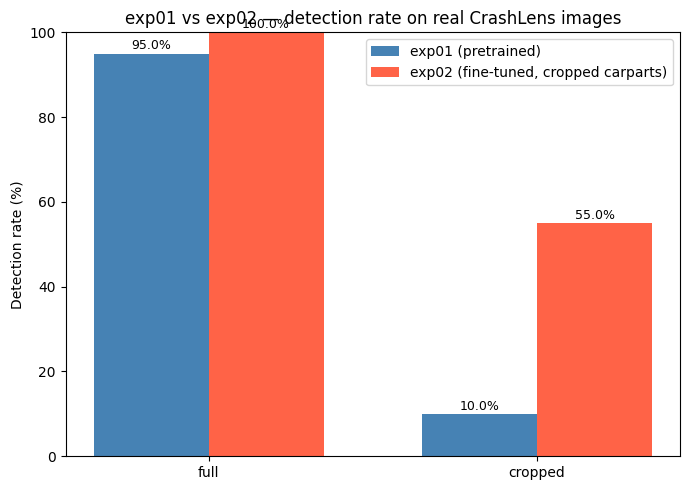

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/real_eval_chart.png


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
x = range(len(comparison_df))
width = 0.35
ax.bar([i - width / 2 for i in x], comparison_df['exp01_detection_rate_pct'], width, label='exp01 (pretrained)', color='steelblue')
ax.bar([i + width / 2 for i in x], comparison_df['exp02_detection_rate_pct'], width, label='exp02 (fine-tuned, cropped carparts)', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df['subfolder'])
ax.set_ylim(0, 100)
ax.set_ylabel('Detection rate (%)')
ax.set_title('exp01 vs exp02 — detection rate on real CrashLens images')
ax.legend()
for i, (b, a) in enumerate(zip(comparison_df['exp01_detection_rate_pct'], comparison_df['exp02_detection_rate_pct'])):
    if b is not None:
        ax.text(i - width / 2, b + 1, f'{b}%', ha='center', fontsize=9)
    ax.text(i + width / 2, a + 1, f'{a}%', ha='center', fontsize=9)
plt.tight_layout()
chart_path = os.path.join(EXP_DIR, 'real_eval_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {chart_path}')

## 🗒️ Section 10 — Save `config.yaml` and `notes.md` (docs §8 template)

In [18]:
from datetime import date

# Pull real training-time metrics from Ultralytics' own results.csv (last epoch) — not invented
train_metrics_final = {}
results_csv_path = os.path.join(EXP_DIR, 'results.csv')
if os.path.exists(results_csv_path):
    _tdf = pd.read_csv(results_csv_path)
    _tdf.columns = [c.strip() for c in _tdf.columns]
    last = _tdf.iloc[-1].to_dict()
    train_metrics_final = {k: v for k, v in last.items() if any(t in k for t in ('mAP', 'precision', 'recall'))}

config = {
    'experiment_id': EXP_ID,
    'stage': 'Stage 2 — fine-tune (one variable vs exp01: cropped carparts training data)',
    'reference_experiment': 'exp01_baseline_pretrained',
    'model_source': MODEL_SOURCE,
    'seed': SEED,
    'crop_params': {
        'min_margin_frac': MIN_MARGIN_FRAC, 'max_margin_frac': MAX_MARGIN_FRAC,
        'jitter_frac': JITTER_FRAC, 'min_crop_px': MIN_CROP_PX,
    },
    'dataset_version': DATASET_VERSION,
    'dataset_source': 'carparts-seg.yaml (Ultralytics auto-download)',
    'splits_cropped': SPLITS_TO_CROP,
    'test_split_touched': False,
    'crop_stats': crop_stats,
    'training': {
        'imgsz': IMG_SIZE, 'epochs': EPOCHS, 'seed': SEED,
        'recipe_note': ("Ultralytics default hyperparameters, matching its own documented carparts-seg "
                         "example (epochs=100, imgsz=640) -- no community-training-notebook file found "
                         "in-repo to copy exactly; confirm if a different reference recipe was intended."),
    },
    'eval': {
        'conf_threshold': CONF_THRESH, 'iou_threshold': IOU_THRESH, 'imgsz': IMG_SIZE,
        'real_data_root': REAL_DATA_ROOT, 'kept_identical_to_exp01': True,
    },
    'date': date.today().isoformat(),
}
config_path = os.path.join(EXP_DIR, 'config.yaml')
with open(config_path, 'w') as f:
    yaml.dump(config, f, sort_keys=False)
print(f'✅ Saved → {config_path}')

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/config.yaml


In [19]:
notes_md = f"""# {EXP_ID} — Fine-tune on cropped carparts-seg data
Date: {date.today().isoformat()}
Purpose (one variable under test): Does fine-tuning exp01's pretrained checkpoint on a cropped-around-instance version of the carparts-seg training data recover detection on real CrashLens close-ups? Everything else (checkpoint, eval conf/iou/imgsz, eval images) held identical to exp01.
Dataset version: {DATASET_VERSION} (archived at {DRIVE_DATASETS_DIR}); source = carparts-seg.yaml (Ultralytics auto-download); crop seed = {SEED}; train/val cropped, test untouched
Config (lr, epochs, backbone frozen?, imgsz, augment): Ultralytics defaults (backbone unfrozen), epochs={EPOCHS}, imgsz={IMG_SIZE}, seed={SEED} -- see config.yaml 'training.recipe_note' for provenance caveat
Training metrics (final epoch, from results.csv): {train_metrics_final if train_metrics_final else '(fill in from results.csv/results.png after running -- not available until the notebook executes)'}
Validation metrics (independent set): carparts-seg val split metrics above; real CrashLens detection rate (this experiment's actual target metric) below
Real CrashLens detection rate, before (exp01) -> after (exp02):
"""
for _, crow in comparison_df.iterrows():
    before_txt = f"{crow['exp01_detection_rate_pct']}%" if crow['exp01_detection_rate_pct'] is not None else 'n/a'
    notes_md += f"  - {crow['subfolder']}/: {before_txt} -> {crow['exp02_detection_rate_pct']}%  (delta {crow['delta_pct']:+.2f} pts)\n"

notes_md += f"""Visual predictions (paths): {os.path.join(EXP_DIR, 'val_preds')}/full/, .../cropped/
Strengths: (fill in after reviewing val_preds/ overlays -- did fine-tuning actually fix cropped/ detections, or just lower the bar for weak/wrong ones?)
Weaknesses: (fill in -- note wrong-part vs no-detection vs poor mask quality separately, and whether full/ regressed)
Data/leakage checks done: carparts-seg's own train/val/test split was preserved (only train->train, val->val cropped; test never touched, never trained or evaluated on). Real CrashLens eval images are a separate, disjoint image source from carparts-seg entirely.
Lessons learned: (fill in -- does this support the close-up-framing/domain-shift hypothesis? Is cropped carparts training data enough, or does it still fall short of what real CrashLens close-ups need -- e.g. damage-altered appearance, unusual viewpoints -- pointing at manual/auto-labeled CrashLens-specific data instead?)
Recommended next step: (fill in -- e.g. proceed to CrashLens-specific labeling per docs/segmentation_finetuning.md §3, or iterate on crop parameters, or accept exp02 as sufficient)
"""

notes_path = os.path.join(EXP_DIR, 'notes.md')
with open(notes_path, 'w', encoding='utf-8') as f:
    f.write(notes_md)
print(f'✅ Saved → {notes_path}')
print('⚠️  notes.md has placeholders -- fill in Strengths/Weaknesses/Lessons/Next step after reviewing val_preds/ overlays before calling this experiment finished (per docs/segmentation_finetuning.md §7).')

✅ Saved → /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts/notes.md
⚠️  notes.md has placeholders -- fill in Strengths/Weaknesses/Lessons/Next step after reviewing val_preds/ overlays before calling this experiment finished (per docs/segmentation_finetuning.md §7).


## ✅ Section 11 — Summary

In [20]:
print('=' * 70)
print(f'STAGE 2 — {EXP_ID}')
print('=' * 70)
for _, crow in comparison_df.iterrows():
    before_txt = f"{crow['exp01_detection_rate_pct']}%" if crow['exp01_detection_rate_pct'] is not None else 'n/a'
    print(f"{crow['subfolder']:8s} | exp01: {before_txt:>6s} -> exp02: {crow['exp02_detection_rate_pct']:6.2f}%  (delta {crow['delta_pct']:+.2f} pts)")
print('=' * 70)
print(f'Artifacts saved to: {EXP_DIR}')
print('  - weights/best.pt, weights/last.pt')
print('  - results.csv, results.png (Ultralytics training curves)')
print('  - real_eval_results.csv, real_eval_summary.csv (this experiment\'s actual target metric)')
print('  - real_eval_chart.png, exp01_vs_exp02_comparison.csv')
print('  - val_preds/full/, val_preds/cropped/ (annotated overlays)')
print('  - config.yaml, notes.md')
print()
print('Next: review val_preds/ overlays, fill in notes.md, then decide the Stage 2/3 direction per docs/segmentation_finetuning.md.')

STAGE 2 — exp02_finetune_cropped_carparts
full     | exp01:  95.0% -> exp02: 100.00%  (delta +5.00 pts)
cropped  | exp01:  10.0% -> exp02:  55.00%  (delta +45.00 pts)
Artifacts saved to: /content/drive/MyDrive/carparts/segmentation/experiments/exp02_finetune_cropped_carparts
  - weights/best.pt, weights/last.pt
  - results.csv, results.png (Ultralytics training curves)
  - real_eval_results.csv, real_eval_summary.csv (this experiment's actual target metric)
  - real_eval_chart.png, exp01_vs_exp02_comparison.csv
  - val_preds/full/, val_preds/cropped/ (annotated overlays)
  - config.yaml, notes.md

Next: review val_preds/ overlays, fill in notes.md, then decide the Stage 2/3 direction per docs/segmentation_finetuning.md.
